In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

In [13]:
def plot_points(features, labels):
    X = np.array(features)
    y = np.array(labels)
    spam = X[np.argwhere(y==1)]
    ham = X[np.argwhere(y==0)]
    plt.scatter([s[0][0] for s in spam],
                   [s[0][1] for s in spam],
                   s = 35,
                   color = 'cyan',
                   edgecolor = 'k',
                   marker = '^')
    plt.scatter([s[0][0] for s in ham],
                   [s[0][1] for s in ham],
                   s = 25,
                   color = 'red',
                   edgecolor = 'k',
                   marker = 's')
    plt.xlabel('x_1')
    plt.ylabel('x_2')
    plt.legend(['label 1','label 0'])

def plot_model(X, y, model):
    X = np.array(X)
    y = np.array(y)
    plot_step = 0.01
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z,colors = 'k',linewidths = 3)
    plot_points(X, y)
    plt.contourf(xx, yy, Z, colors=['red', 'blue'], alpha=0.2, levels=range(-1,2))
    plt.show()

# Building an SVM to separate a linear dataset

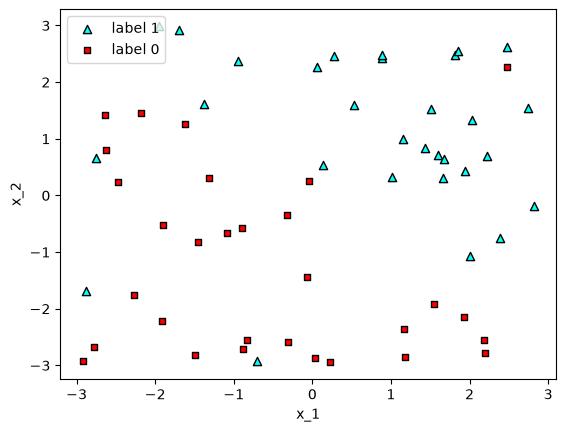

In [14]:
# Loading the linear dataset

linear_data = pd.read_csv('linear.csv')
features = np.array(linear_data[['x_1', 'x_2']])
labels = np.array(linear_data['y'])
plot_points(features, labels)

Accuracy: 0.9333333333333333


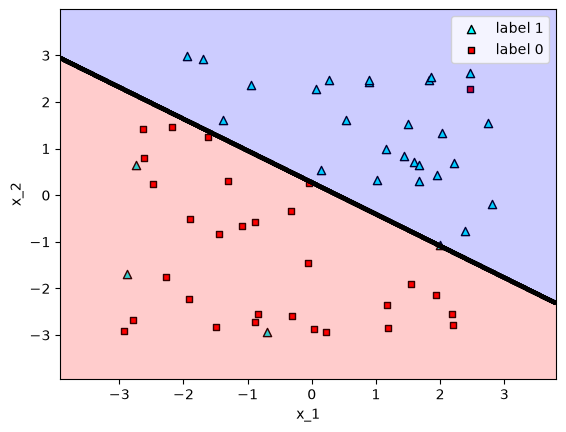

In [15]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(features, labels)
print("Accuracy:", svm_linear.score(features, labels))
plot_model(features, labels, svm_linear)

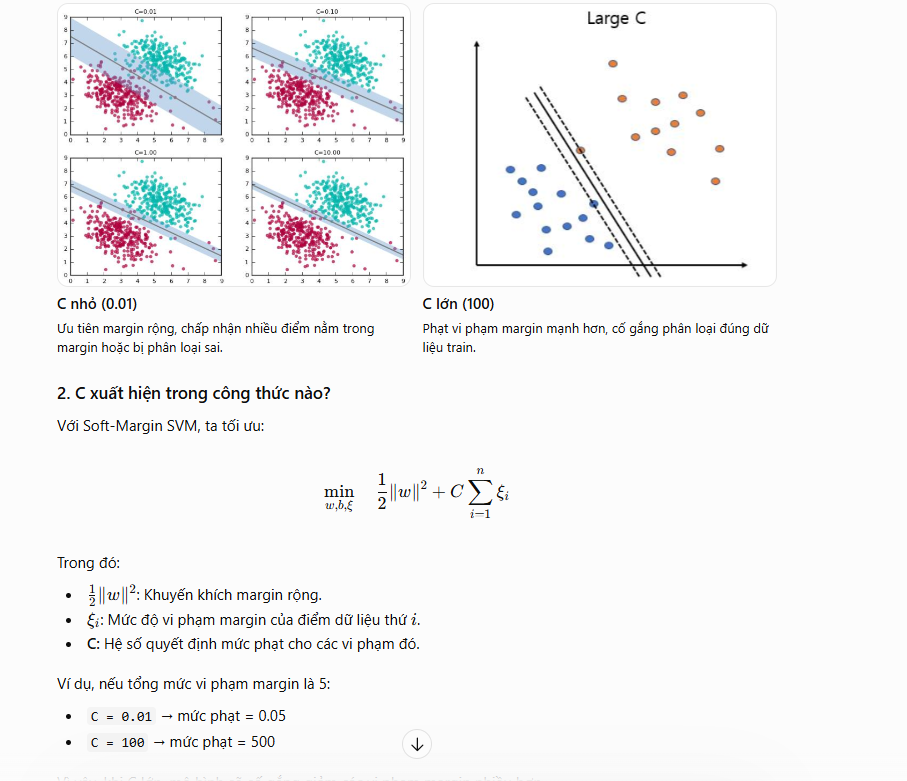

C = 0.01
Accuracy: 0.8667


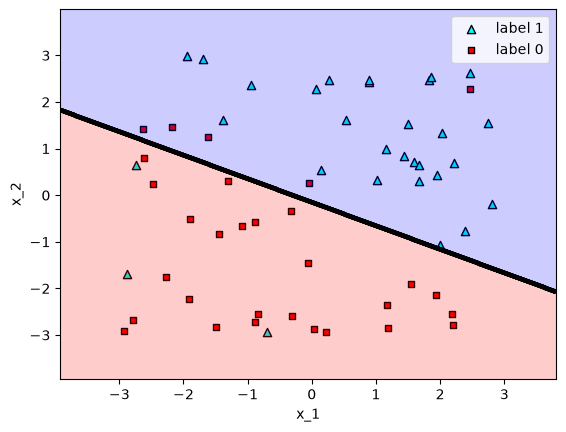

C = 0.1
Accuracy: 0.9167


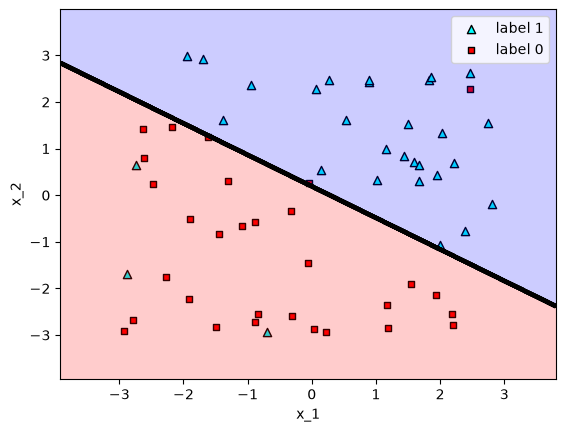

C = 1
Accuracy: 0.9333


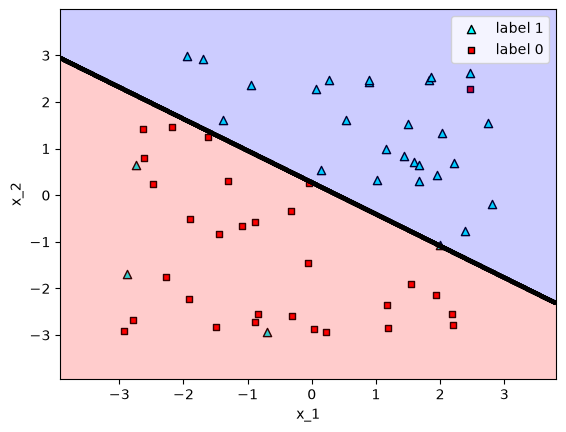

C = 10
Accuracy: 0.9167


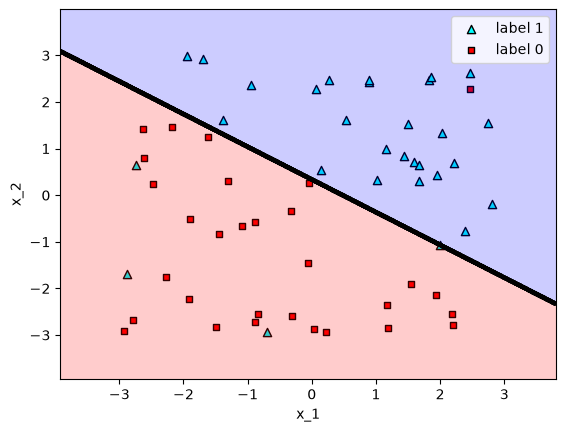

C = 100
Accuracy: 0.9167


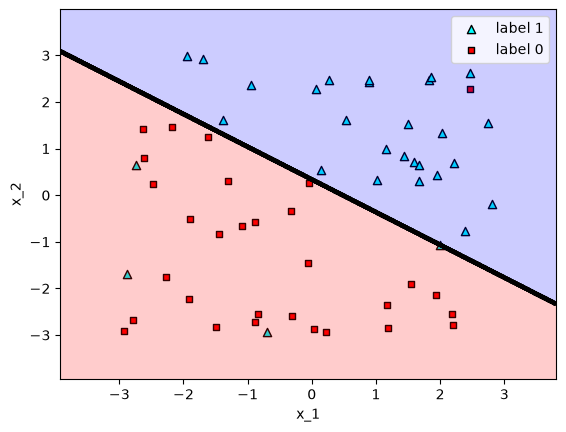

In [16]:
C_values = [0.01, 0.1, 1, 10, 100]

for c in C_values:
    model = SVC(kernel='linear', C=c)
    model.fit(features, labels)

    print(f"C = {c}")
    print(f"Accuracy: {model.score(features, labels):.4f}")

    plot_model(features, labels, model)

# Building polynomial kernels for a circular dataset

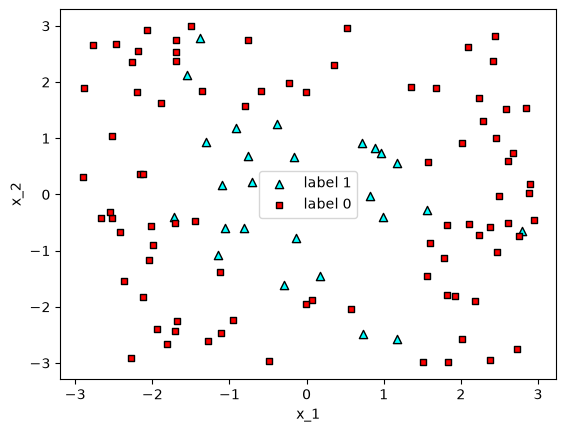

In [17]:
# Loading the one_circle dataset

circular_data = pd.read_csv('./../one_circle.csv')
features = np.array(circular_data[['x_1', 'x_2']])
labels = np.array(circular_data['y'])
plot_points(features, labels)

Polynomial kernel of degree = 2
Accuracy: 0.8909090909090909


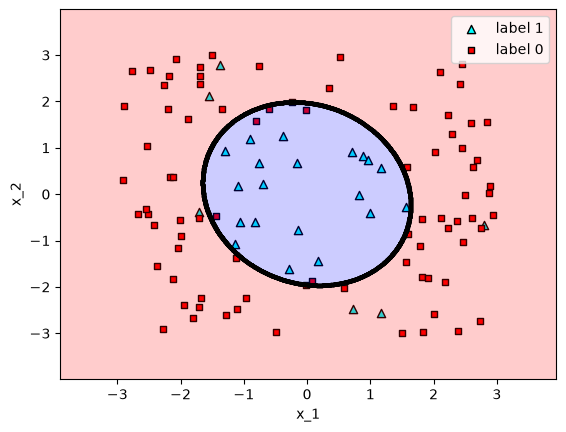

Polynomial kernel of degree = 4
Accuracy: 0.9


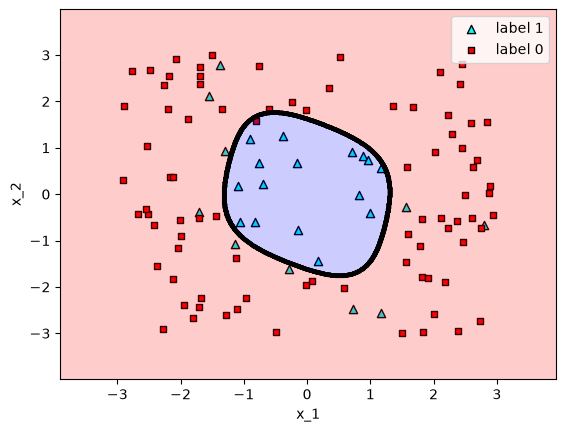

In [ ]:
# Degree = 2
svm_degree_2 = SVC(kernel='poly', degree=2)
svm_degree_2.fit(features, labels)
print("Polynomial kernel of degree = 2")
print("Accuracy:", svm_degree_2.score(features, labels))
plot_model(features, labels, svm_degree_2)

# Degree = 4
svm_degree_4 = SVC(kernel='poly', degree=4)
svm_degree_4.fit(features, labels)
print("Polynomial kernel of degree = 4")
print("Accuracy:", svm_degree_4.score(features, labels))
plot_model(features, labels, svm_degree_4)

"""degree là bậc của đa thức trong Polynomial Kernel, từ đó quyết định bậc tối đa của phương trình mô tả Decision Boundary trong không gian đầu vào. """

# Experimenting with gammas in the rbf kernel

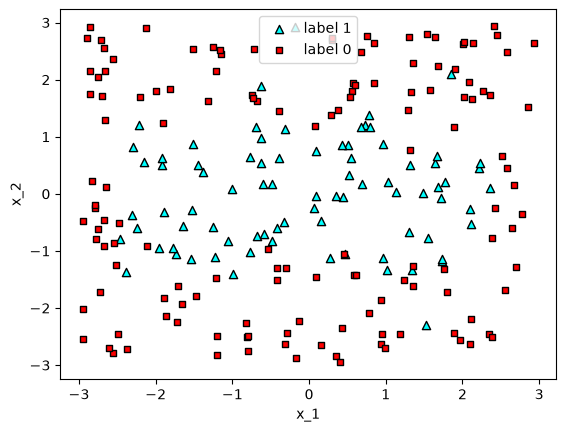

In [19]:
# Loading the two_circles dataset

two_circles_data = pd.read_csv('two_circles.csv')
features = np.array(two_circles_data[['x_1', 'x_2']])
labels = np.array(two_circles_data['y'])
plot_points(features, labels)

Gamma = 0
Accuracy: 0.6318


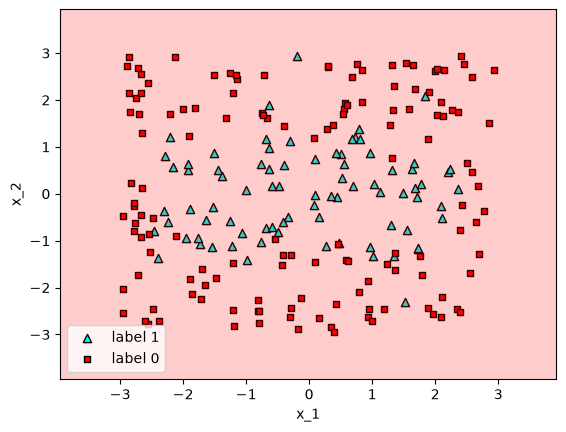

Gamma = 0.1
Accuracy: 0.8773


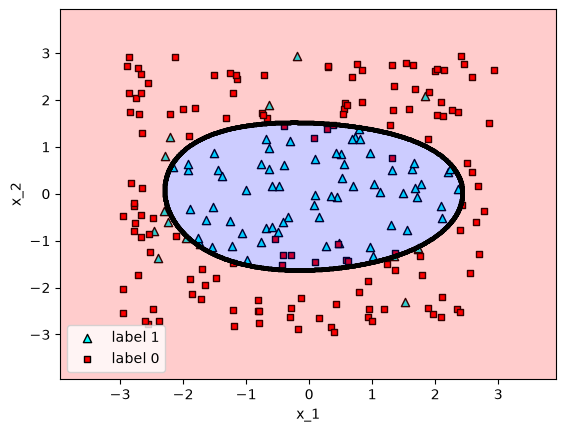

Gamma = 1
Accuracy: 0.9045


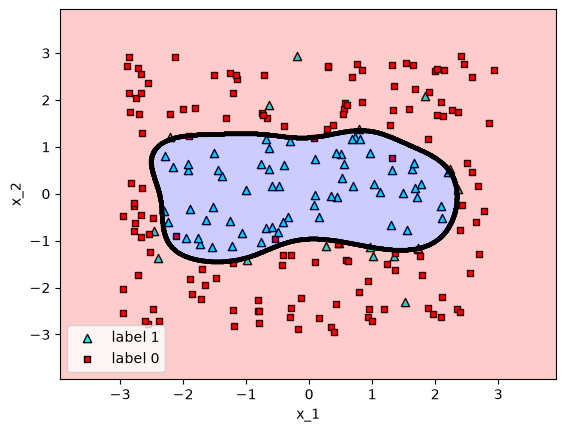

Gamma = 10
Accuracy: 0.9636


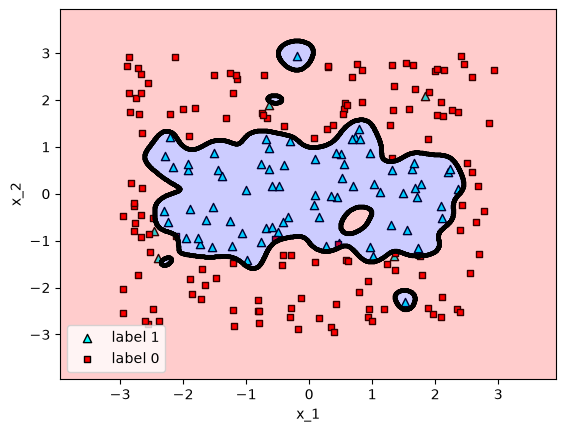

Gamma = 100
Accuracy: 0.9909


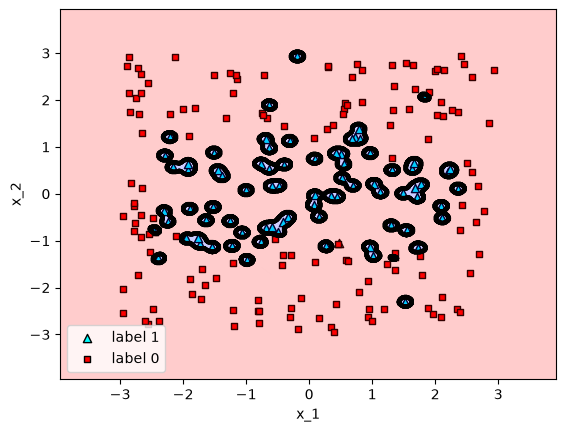

In [21]:
# gamma = 0.1

[0, 0.1, 1, 10, 100]

for gamma in [0, 0.1, 1, 10, 100]:
    model = SVC(kernel='rbf', gamma=gamma)
    model.fit(features, labels)

    print(f"Gamma = {gamma}")
    print(f"Accuracy: {model.score(features, labels):.4f}")

    plot_model(features, labels, model)
